# 01 Gold Sql Validation


  01_gold_sql_validation
DB     : C:\Users\miy\Downloads\1000_논문투고\1_양문일_교신저자\23_언더라이팅_Text_to_SQL\insurance-underwriting-nl2sql-benchmark\data\insurance_uw.db
Font   : Malgun Gothic

질문셋 로드: 80개

─────────────────────────────────────────────
  전체 질문         :   80개
  실행 성공         :   80개  (100.0%)
  실행 오류         :    0개  (0.0%)
  결과 비어있음      :   16개  (성공 중)
  유효 결과(비어있지 않음):   64개  (80.0%)
─────────────────────────────────────────────

✅ 실행 오류 없음

[빈 결과 목록] — 샘플 데이터 부족 가능성
question_id category  difficulty
      UW030    장해리스크 challenging
      UW047    보험료산출    moderate
      UW049    보험료산출    moderate
      UW053     계약관리 challenging
      UW054     계약관리 challenging
      UW057     계약심사    moderate
      UW059     계약관리    moderate
      UW067     계약심사    moderate
      UW069     사기탐지 challenging
      UW072     고지의무 challenging
      UW073     사기탐지 challenging
      UW074    보험료산출    moderate
      UW076    보험금지급    moderate
      UW077    보험료산출 challenging
      UW078    보험료산출 ch

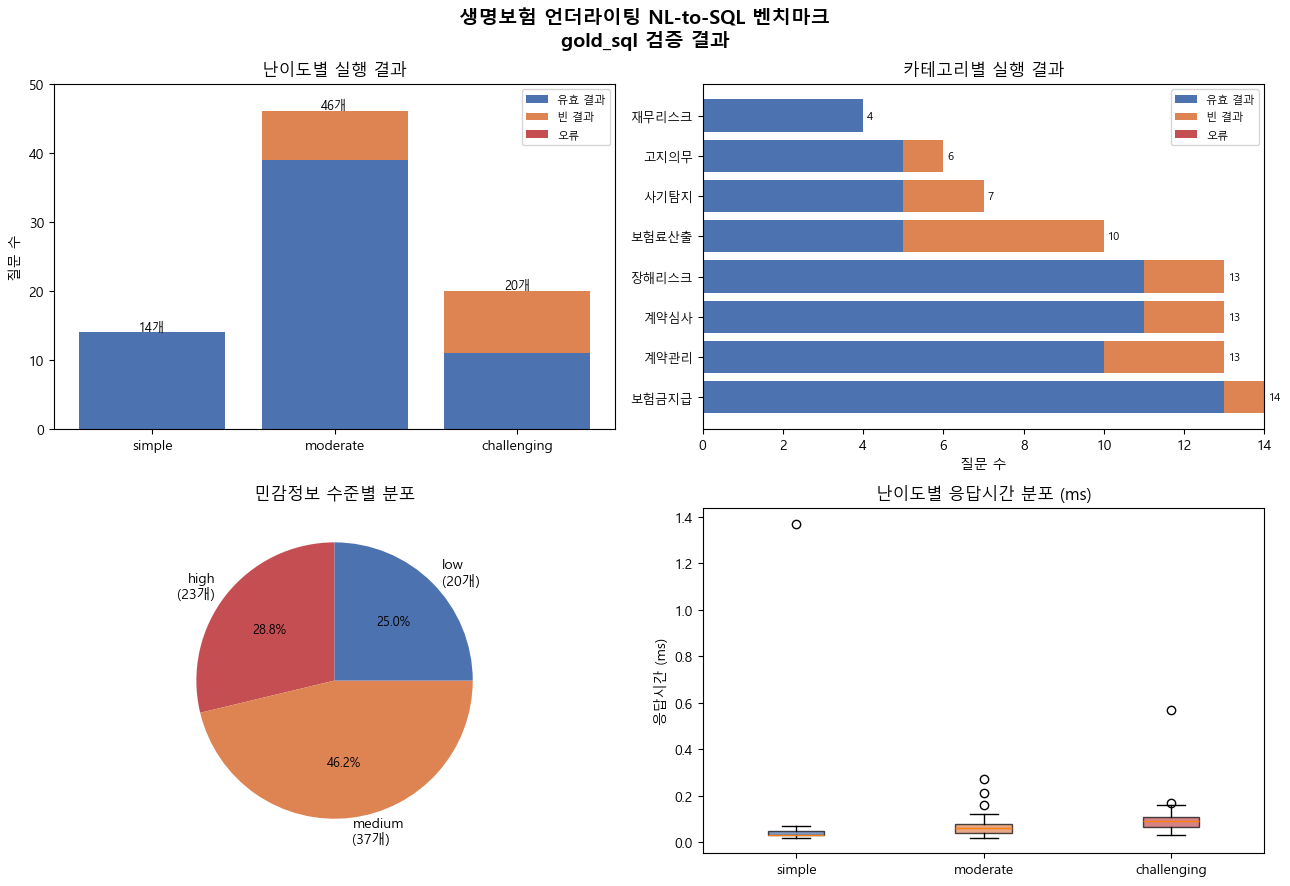


그래프 저장: C:\Users\miy\Downloads\1000_논문투고\1_양문일_교신저자\23_언더라이팅_Text_to_SQL\insurance-underwriting-nl2sql-benchmark\results\figures\01_gold_sql_validation.png

  최종 벤치마크 검증 리포트
  질문셋 버전       : v2.0
  총 질문 수        : 80개
  출처 문서         : 생명보험 표준약관, 보험업감독규정
  SQL 방언          : SQLite
  gold_sql 실행 성공: 80/80 (100.0%)
  유효 결과         : 64/80 (80.0%)
  평균 응답시간      : 0.09 ms
  중간 응답시간      : 0.06 ms

  [난이도 분포]
    simple      : 14개 (17.5%)
    moderate    : 46개 (57.5%)
    challenging : 20개 (25.0%)

  [민감정보 분포]
    high    : 23개 (28.7%)
    medium  : 37개 (46.2%)
    low     : 20개 (25.0%)

검증 결과 저장: C:\Users\miy\Downloads\1000_논문투고\1_양문일_교신저자\23_언더라이팅_Text_to_SQL\insurance-underwriting-nl2sql-benchmark\results\raw\gold_sql_validation.csv

다음: 02_experiment_text2sql.ipynb 실행


In [2]:
# ============================================================
# 01_gold_sql_validation.ipynb
# gold_sql 전수 검증: 실행 가능성 + 결과 비어있음 여부 +
# 난이도·카테고리별 분석 + 최종 벤치마크 리포트
# ============================================================

# %% [1] 라이브러리 & 경로
import sqlite3
import json
import os
import time
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

ROOT    = Path(os.getcwd())
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DB_PATH  = ROOT / "data"      / "insurance_uw.db"
Q1_PATH  = ROOT / "benchmark" / "questionset_v2_part1.json"
Q2_PATH  = ROOT / "benchmark" / "questionset_v2_part2.json"
FIG_DIR  = ROOT / "results"   / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── 한글 폰트 설정 (Windows)
font_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]
available = {f.name for f in fm.fontManager.ttflist}
kor_font  = next((f for f in font_candidates if f in available), "DejaVu Sans")
matplotlib.rc("font", family=kor_font)
matplotlib.rc("axes", unicode_minus=False)

print("=" * 55)
print("  01_gold_sql_validation")
print("=" * 55)
print(f"DB     : {DB_PATH}")
print(f"Font   : {kor_font}")
assert DB_PATH.exists(), "DB 없음 → 00_setup 먼저 실행하세요"


# %% [2] 질문셋 로드
def load_qs(path: Path) -> list[dict]:
    with open(path, encoding="utf-8") as f:
        d = json.load(f)
    return d if isinstance(d, list) else d.get("questions", [])

all_qs = load_qs(Q1_PATH) + load_qs(Q2_PATH)
print(f"\n질문셋 로드: {len(all_qs)}개")


# %% [3] gold_sql 전수 실행 검증
conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA foreign_keys = ON")

results = []
for q in all_qs:
    qid      = q["question_id"]
    sql      = q.get("gold_sql", "")
    cat      = q.get("category", "")
    diff     = q.get("difficulty", "")
    sil      = q.get("sensitive_info_level", "")

    t0 = time.perf_counter()
    try:
        cur  = conn.execute(sql)
        rows = cur.fetchall()
        elapsed = (time.perf_counter() - t0) * 1000  # ms
        is_empty = (len(rows) == 0)
        results.append({
            "question_id"         : qid,
            "category"            : cat,
            "difficulty"          : diff,
            "sensitive_info_level": sil,
            "status"              : "success",
            "row_count"           : len(rows),
            "is_empty"            : is_empty,
            "elapsed_ms"          : round(elapsed, 2),
            "error"               : None,
        })
    except Exception as e:
        elapsed = (time.perf_counter() - t0) * 1000
        results.append({
            "question_id"         : qid,
            "category"            : cat,
            "difficulty"          : diff,
            "sensitive_info_level": sil,
            "status"              : "error",
            "row_count"           : 0,
            "is_empty"            : True,
            "elapsed_ms"          : round(elapsed, 2),
            "error"               : str(e),
        })

conn.close()
df = pd.DataFrame(results)

# 요약
n_total   = len(df)
n_success = (df["status"] == "success").sum()
n_error   = (df["status"] == "error").sum()
n_empty   = ((df["status"] == "success") & df["is_empty"]).sum()
n_valid   = n_success - n_empty

print(f"\n{'─'*45}")
print(f"  전체 질문         : {n_total:>4}개")
print(f"  실행 성공         : {n_success:>4}개  ({n_success/n_total*100:.1f}%)")
print(f"  실행 오류         : {n_error:>4}개  ({n_error/n_total*100:.1f}%)")
print(f"  결과 비어있음      : {n_empty:>4}개  (성공 중)")
print(f"  유효 결과(비어있지 않음): {n_valid:>4}개  ({n_valid/n_total*100:.1f}%)")
print(f"{'─'*45}")


# %% [4] 오류 목록 출력
if n_error > 0:
    print("\n[오류 목록]")
    err_df = df[df["status"] == "error"][["question_id","category","difficulty","error"]]
    print(err_df.to_string(index=False))
else:
    print("\n✅ 실행 오류 없음")

# 빈 결과 목록
if n_empty > 0:
    print("\n[빈 결과 목록] — 샘플 데이터 부족 가능성")
    emp_df = df[(df["status"]=="success") & df["is_empty"]][["question_id","category","difficulty"]]
    print(emp_df.to_string(index=False))
else:
    print("✅ 빈 결과 없음")


# %% [5] 난이도별 분석
print("\n[난이도별 실행 결과]")
diff_order = ["simple","moderate","challenging"]
diff_stats = (
    df.groupby("difficulty")
    .agg(
        전체=("status","count"),
        성공=("status", lambda x: (x=="success").sum()),
        오류=("status", lambda x: (x=="error").sum()),
        빈결과=("is_empty", lambda x: x[df.loc[x.index,"status"]=="success"].sum()),
        평균응답ms=("elapsed_ms","mean"),
    )
    .reindex(diff_order)
    .round(2)
)
diff_stats["성공률(%)"] = (diff_stats["성공"] / diff_stats["전체"] * 100).round(1)
print(diff_stats.to_string())


# %% [6] 카테고리별 분석
print("\n[카테고리별 실행 결과]")
cat_stats = (
    df.groupby("category")
    .agg(
        전체=("status","count"),
        성공=("status", lambda x: (x=="success").sum()),
        오류=("status", lambda x: (x=="error").sum()),
        빈결과=("is_empty", lambda x: x[df.loc[x.index,"status"]=="success"].sum()),
        평균응답ms=("elapsed_ms","mean"),
    )
    .sort_values("전체", ascending=False)
    .round(2)
)
cat_stats["성공률(%)"] = (cat_stats["성공"] / cat_stats["전체"] * 100).round(1)
print(cat_stats.to_string())


# %% [7] 민감정보 수준별 분석
print("\n[민감정보 수준별 분포]")
sil_order = ["high","medium","low"]
sil_stats = (
    df.groupby("sensitive_info_level")
    .agg(전체=("status","count"),
         성공=("status", lambda x: (x=="success").sum()))
    .reindex(sil_order)
)
sil_stats["성공률(%)"] = (sil_stats["성공"] / sil_stats["전체"] * 100).round(1)
print(sil_stats.to_string())


# %% [8] 시각화
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("생명보험 언더라이팅 NL-to-SQL 벤치마크\ngold_sql 검증 결과", fontsize=14, fontweight="bold")

# ── 8-1. 난이도별 성공/오류/빈결과 stacked bar
ax = axes[0, 0]
bottom_s = diff_stats["성공"] - diff_stats["빈결과"]
ax.bar(diff_order, bottom_s,             color="#4C72B0", label="유효 결과")
ax.bar(diff_order, diff_stats["빈결과"], color="#DD8452", label="빈 결과",   bottom=bottom_s)
ax.bar(diff_order, diff_stats["오류"],   color="#C44E52", label="오류",
       bottom=diff_stats["성공"])
for i, d in enumerate(diff_order):
    tot = diff_stats.loc[d, "전체"]
    ax.text(i, tot + 0.3, f'{tot}개', ha="center", fontsize=9)
ax.set_title("난이도별 실행 결과")
ax.set_ylabel("질문 수")
ax.legend(fontsize=8)
ax.set_ylim(0, diff_stats["전체"].max() + 4)

# ── 8-2. 카테고리별 수평 bar
ax = axes[0, 1]
cats  = cat_stats.index.tolist()
totals= cat_stats["전체"].values
valids= (cat_stats["성공"] - cat_stats["빈결과"]).values
empties = cat_stats["빈결과"].values
errors  = cat_stats["오류"].values
y = range(len(cats))
ax.barh(y, valids,              color="#4C72B0", label="유효 결과")
ax.barh(y, empties, left=valids,color="#DD8452", label="빈 결과")
ax.barh(y, errors,  left=cat_stats["성공"].values, color="#C44E52", label="오류")
ax.set_yticks(list(y))
ax.set_yticklabels(cats, fontsize=9)
ax.set_title("카테고리별 실행 결과")
ax.set_xlabel("질문 수")
ax.legend(fontsize=8)
for i, (v, t) in enumerate(zip(valids + empties + errors, totals)):
    ax.text(t + 0.1, i, f'{t}', va="center", fontsize=8)

# ── 8-3. 민감정보 수준별 파이
ax = axes[1, 0]
sil_counts = [sil_stats.loc[s, "전체"] for s in sil_order]
colors_sil  = ["#C44E52","#DD8452","#4C72B0"]
wedges, texts, autotexts = ax.pie(
    sil_counts,
    labels=[f"{s}\n({c}개)" for s, c in zip(sil_order, sil_counts)],
    colors=colors_sil,
    autopct="%1.1f%%",
    startangle=90,
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title("민감정보 수준별 분포")

# ── 8-4. 응답시간 분포 (boxplot)
ax = axes[1, 1]
succ_df = df[df["status"] == "success"]
data_by_diff = [
    succ_df[succ_df["difficulty"] == d]["elapsed_ms"].values
    for d in diff_order
]
bp = ax.boxplot(data_by_diff, tick_labels=diff_order, patch_artist=True)
box_colors = ["#4C72B0","#DD8452","#C44E52"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("난이도별 응답시간 분포 (ms)")
ax.set_ylabel("응답시간 (ms)")

plt.tight_layout()
fig_path = FIG_DIR / "01_gold_sql_validation.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n그래프 저장: {fig_path}")


# %% [9] 최종 벤치마크 리포트
print("\n" + "=" * 55)
print("  최종 벤치마크 검증 리포트")
print("=" * 55)
print(f"  질문셋 버전       : v2.0")
print(f"  총 질문 수        : {n_total}개")
print(f"  출처 문서         : 생명보험 표준약관, 보험업감독규정")
print(f"  SQL 방언          : SQLite")
print(f"  gold_sql 실행 성공: {n_success}/{n_total} ({n_success/n_total*100:.1f}%)")
print(f"  유효 결과         : {n_valid}/{n_total} ({n_valid/n_total*100:.1f}%)")
print(f"  평균 응답시간      : {df['elapsed_ms'].mean():.2f} ms")
print(f"  중간 응답시간      : {df['elapsed_ms'].median():.2f} ms")
print()
print("  [난이도 분포]")
for d in diff_order:
    n = int(diff_stats.loc[d,"전체"]) if d in diff_stats.index else 0
    print(f"    {d:<12}: {n}개 ({n/n_total*100:.1f}%)")
print()
print("  [민감정보 분포]")
for s in sil_order:
    n = int(sil_stats.loc[s,"전체"]) if s in sil_stats.index else 0
    print(f"    {s:<8}: {n}개 ({n/n_total*100:.1f}%)")
print("=" * 55)


# %% [10] 검증 결과 CSV 저장
csv_path = ROOT / "results" / "raw" / "gold_sql_validation.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"\n검증 결과 저장: {csv_path}")
print("\n다음: 02_experiment_text2sql.ipynb 실행")